# Previous versus track-aware GlobalFit
Compare the same generated events and lightmap before and after track-aware clustering. The synchronized display uses the established GlobalFit style: fibre charge from 1 to 150 PE, fit-selected fibres in black, MC truth in green, and the fitted line in red.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'double_hg_event_comparison_tools.py').exists():
    NOTEBOOK_DIR = Path('/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/GlobalFitTest')
sys.path.insert(0, str(NOTEBOOK_DIR))
import importlib
import double_hg_event_comparison_tools as comparison_tools
importlib.reload(comparison_tools)
from double_hg_event_comparison_tools import *
import column_fit_notebook_tools as column_tools
importlib.reload(column_tools)
from column_fit_notebook_tools import (load_truth, segment_line_residuals, plot_line_residuals,
    load_studies, match_columns_to_truth, mip_prior_variants, mip_prior_summary,
    plot_column_resolution, plot_column_charge_distributions,
    plot_relative_energy_resolution, plot_mip_event_profiles, _tree_frame)
plt.rcParams.update({'figure.dpi': 110})

## Configuration
Choose the energy, lightmap model, and scattering length. Available combinations are printed before loading.

In [2]:
ENERGY = '0p7GeV'  # '5GeV' or '0p7GeV'
LIGHTMAP_MODEL = 'Double-HG'  # 'Double-HG' or 'Legacy lightmap'
SCATTER_LENGTH_MM = 0.25
BASE = Path('/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie') / ENERGY / 'maps'
available = discover_reconstruction_pairs(BASE)
if not available:
    raise FileNotFoundError(f'No directory under {BASE} contains both global_fit.root and global_fit_columns_track_aware.root')
available_table = pd.DataFrame([{'lightmap_model': model, 'scatter_length_mm': scatter, 'directory': str(path)} for (model, scatter), path in available.items()])
display(available_table.sort_values(['lightmap_model','scatter_length_mm']))
DIRECTORY = available[(LIGHTMAP_MODEL, float(SCATTER_LENGTH_MM))]
runs, truth = load_reconstruction_pair(DIRECTORY)
events = common_events(runs)
print(f'{len(events)} common events: {events[0]}..{events[-1]}')

,lightmap_model,scatter_length_mm,directory
5,Double-HG,0.25,/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/...
0,Double-HG,0.40,/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/...
6,Double-HG,0.70,/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/...
1,Double-HG,1.00,/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/...
3,Legacy lightmap,0.25,/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/...
7,Legacy lightmap,0.40,/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/...
4,Legacy lightmap,0.70,/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/...
2,Legacy lightmap,1.00,/home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/...


Loading Previous fit: /home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie/0p7GeV/maps/10bin_5m_double_hg_0p25mm_g-0p5_rfb-0p75_fibre-1p0mm_scin-ri-1p48_100kPhotons/global_fit.root
Loading Track-aware fit: /home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie/0p7GeV/maps/10bin_5m_double_hg_0p25mm_g-0p5_rfb-0p75_fibre-1p0mm_scin-ri-1p48_100kPhotons/global_fit_columns_track_aware.root
505 common events: 0..504


## Synchronized event display
The previous fit is on the left and the track-aware fit is on the right. A negative threshold uses each file's stored threshold.

In [3]:
interactive_pair(runs, truth);

Output()

### Widget-free fallback

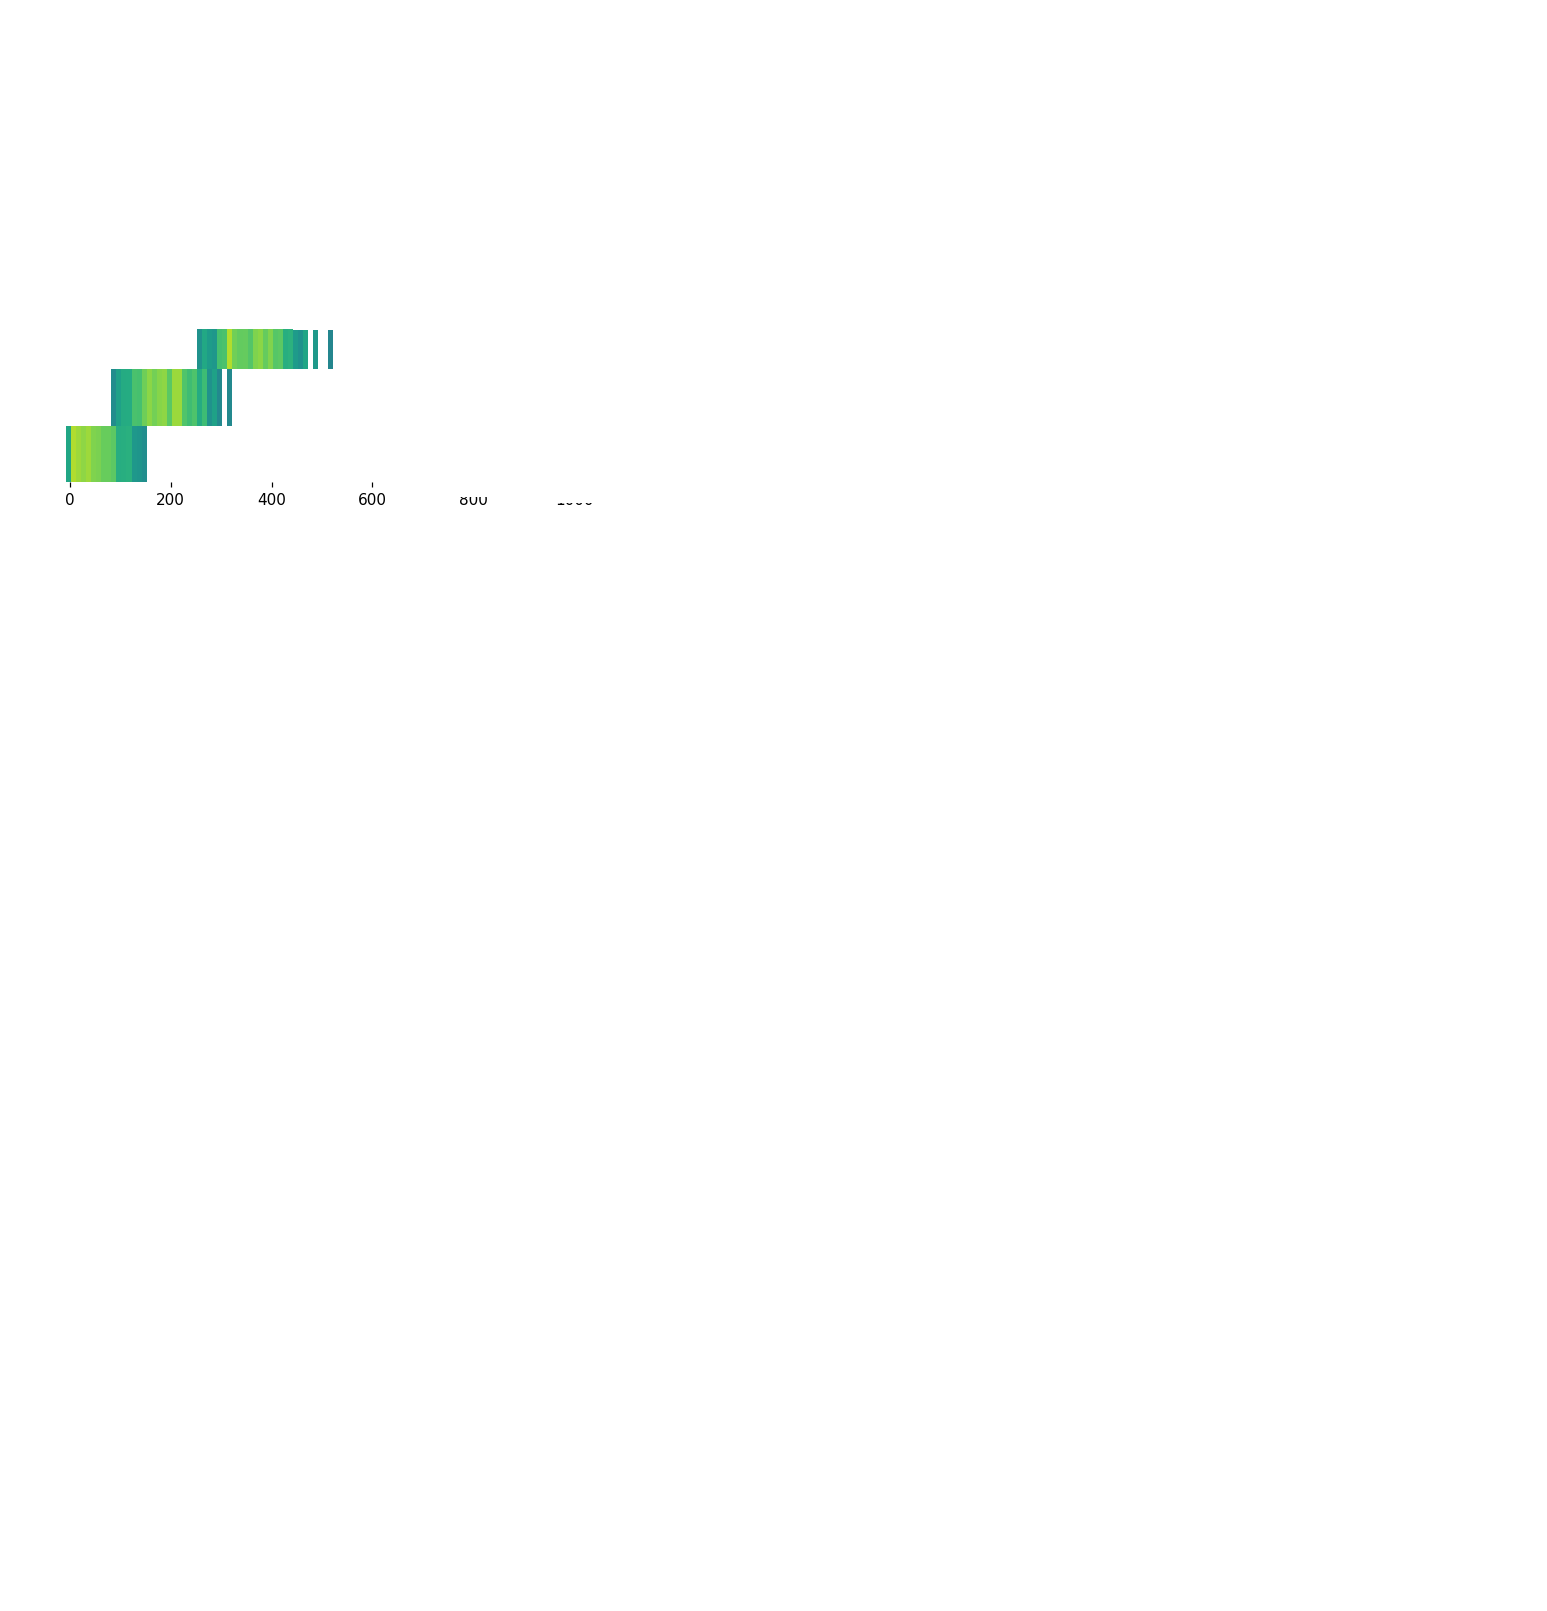

In [4]:
EVENT = events[0]
draw_paired_event(runs, truth, EVENT, threshold=None, log_charge=True, show_mc=True, show_fit=True, show_selected=True, charge_min=1, charge_max=150);

## Step-by-step event retention
Counts are evaluated on events present in each output. The table distinguishes input fibres, post-clustering fibres, final fit fibres, successful Minuit status, and events common to both files.

In [5]:
common = set(events)
loss_rows = []
for label, run in runs.items():
    f = run['fit']
    loss_rows.append({
        'method': label,
        'output events': int(f.event.nunique()),
        'common events': int(f.event.astype(int).isin(common).sum()),
        'mean input fibres': f.observations_before_clustering.mean(),
        'mean post-clustering fibres': f.observations_after_dbscan.mean(),
        'mean final fibres': f.observations.mean(),
        'status 0 events': int((f.status == 0).sum()),
        'status 5 events': int((f.status == 5).sum()),
    })
display(pd.DataFrame(loss_rows).set_index('method'))

,output events,common events,mean input fibres,mean post-clustering fibres,mean final fibres,status 0 events,status 5 events
method,,,,,,,
Previous fit,505,505,313.031683,252.873267,252.873267,0,283
Track-aware fit,505,505,482.423762,469.275248,469.275248,0,397


## Fibre-response controls

In [6]:
event_controls, input_figure = plot_input_controls(runs)
display(event_controls.groupby('model')[['hit_count','total_charge','maximum_charge']].agg(['mean','std','median']))

hit_count                    total_charge               \
                       mean        std median          mean          std   
model                                                                      
Previous fit     544.077228  22.986624  540.0  15265.551503  1037.805539   
Track-aware fit  544.077228  22.986624  540.0  15265.551503  1037.805539   

                              maximum_charge                          
                       median           mean         std      median  
model                                                                 
Previous fit     15137.076341     735.078897  292.691416  643.462524  
Track-aware fit  15137.076341     735.078897  292.691416  643.462524

## Fit controls

,events,status0_fraction,status5_fraction,median_edm,median_chi2_ndof,median_seed_fit_angle_deg
model,,,,,,
Previous fit,505,0.0,0.560396,0.009104,21.114174,3.785217
Track-aware fit,505,0.0,0.786139,0.007593,9.690054,0.259852


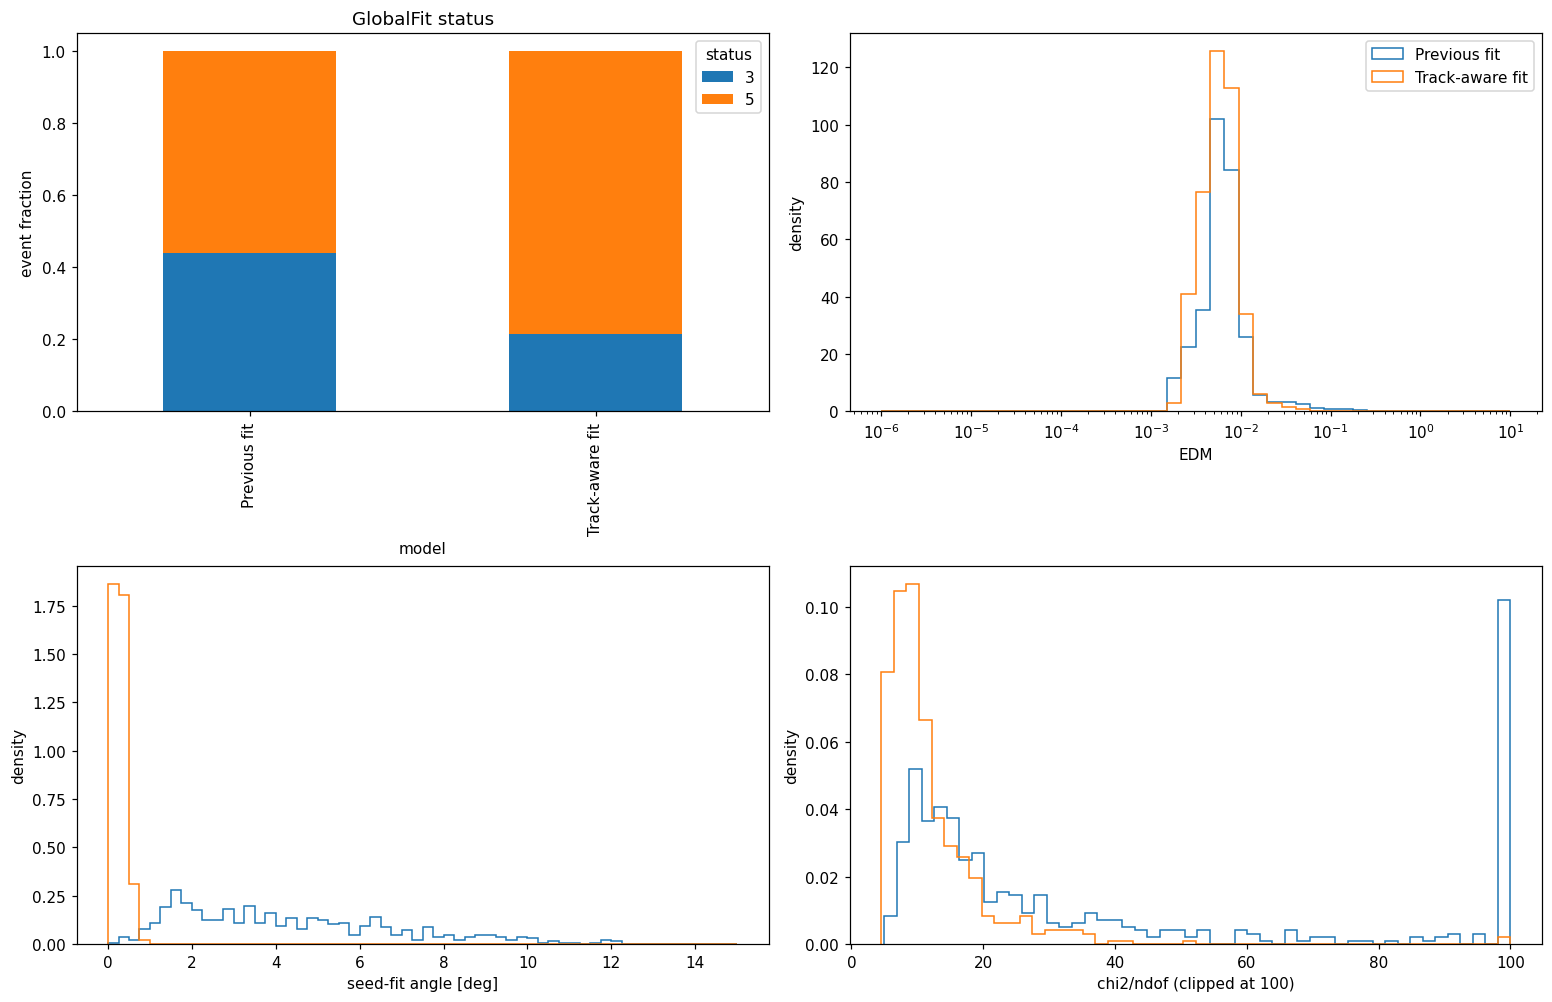

In [7]:
fit_controls, fit_figure = plot_fit_controls(runs)
display(fit_controls.groupby('model').agg(events=('event','nunique'), status0_fraction=('status',lambda x:(x==0).mean()), status5_fraction=('status',lambda x:(x==5).mean()), median_edm=('edm','median'), median_chi2_ndof=('chi2_ndof','median'), median_seed_fit_angle_deg=('seed_fit_angle_deg','median')))

## Track-direction resolution
The absolute angle is calculated between the reconstructed GlobalFit direction and the independent straight line fitted to primary-muon MC cube-start positions. Set `ACCEPTED_STATUSES` to a tuple such as `(0, 5)` to restrict the comparison, or leave it as `None` for every fitted event.

,method,events,median_deg,68pct_deg,90pct_deg
0,Previous fit,505,2.935703,6.084966,13.421175
1,Track-aware fit,505,1.040715,3.417719,10.887256


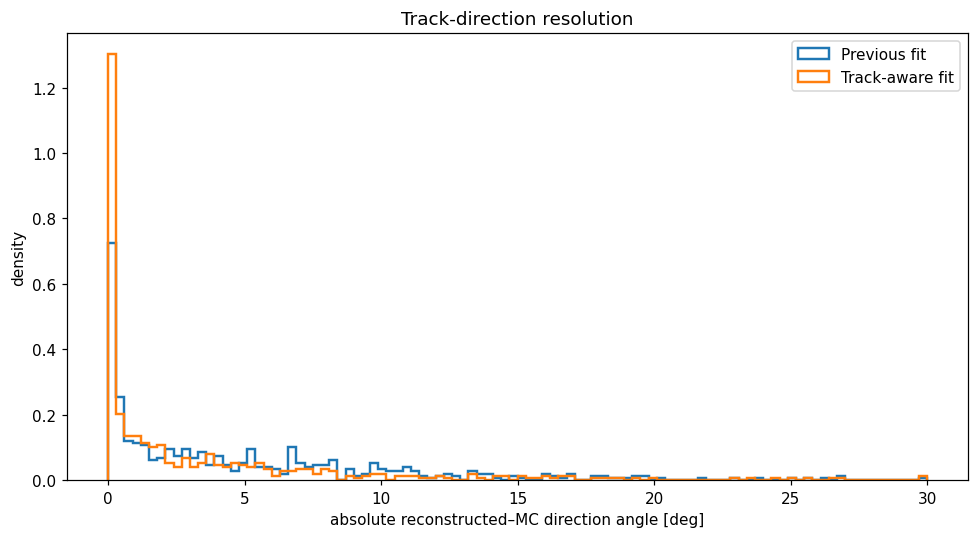

In [8]:
ACCEPTED_STATUSES = None  # for example (0, 5)
DIRECTION_DISPLAY_MAX_DEG = 30
direction_data, direction_summary, direction_figure = plot_direction_resolution(runs, ACCEPTED_STATUSES, maximum_degrees=DIRECTION_DISPLAY_MAX_DEG, bins=100)
display(direction_summary)

## Track point resolution
For every primary-muon cube, these plots show the displacement of its MC segment start from the reconstructed line. `POINT_RESOLUTION_SAMPLES` controls which curves are drawn. The default command shows only the black MC reference and orange track-aware result. Add `'Previous fit'` to that list to restore the blue legacy curve. Gaussian fits use only the configurable central residual interval; the perpendicular distance is summarized by its 68% quantile.

,sample,component,gaussian_mean_mm,gaussian_sigma_mm,fit_low_mm,fit_high_mm,fit_entries,distance_68_mm
0,MC straight-line reference,rx,0.000242,0.067403,-0.5,0.5,19914,NaN
1,MC straight-line reference,ry,0.001619,0.348351,-0.5,0.5,11072,NaN
2,MC straight-line reference,rz,0.002844,0.345540,-0.5,0.5,10709,NaN
3,MC straight-line reference,point_resolution_summary,NaN,0.350207,NaN,NaN,20115,1.271867
4,Track-aware fit,rx,-0.006686,0.103343,-0.5,0.5,19732,NaN
5,Track-aware fit,ry,0.122163,0.737256,-0.5,0.5,5757,NaN
6,Track-aware fit,rz,0.499997,1.425216,-0.5,0.5,5412,NaN
7,Track-aware fit,point_resolution_summary,NaN,1.136985,NaN,NaN,20115,2.743054
8,Previous fit,rx,-0.005301,0.142880,-0.5,0.5,14443,NaN
9,Previous fit,ry,-0.185627,1.224113,-0.5,0.5,3890,NaN


Common events used for point resolution: 505


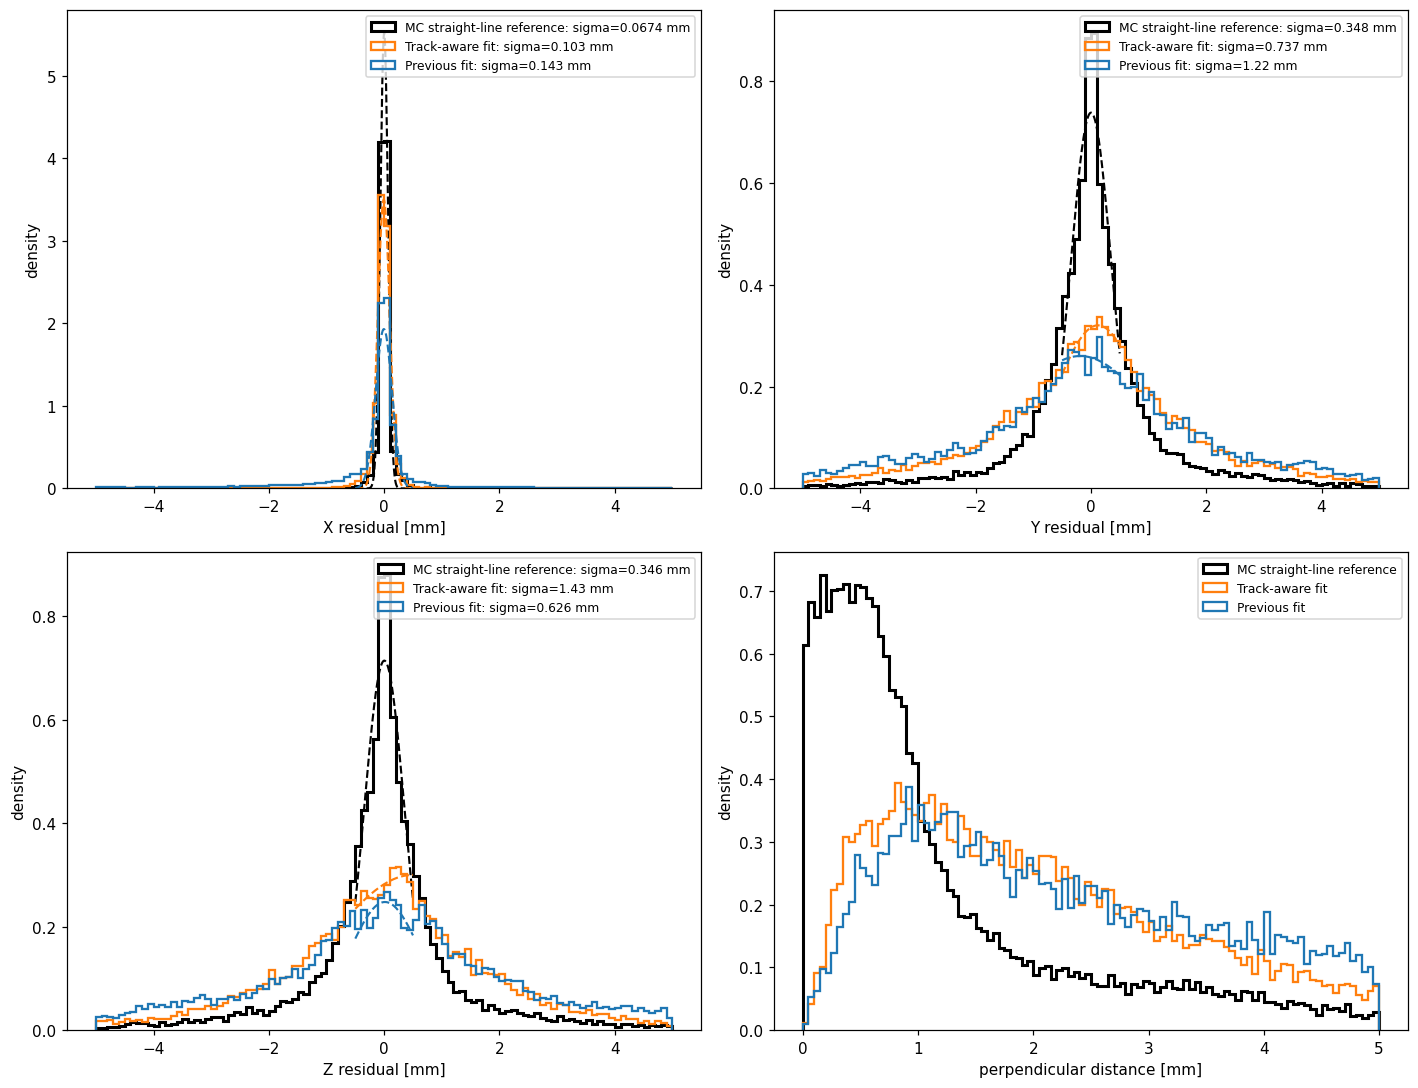

In [9]:
RESIDUAL_DISPLAY_MAX_MM = 5
RESIDUAL_GAUSS_RANGE_MM = (-0.5, 0.5)
# Default: MC (black) + new track-aware result (orange). Add 'Previous fit' for the blue legacy curve.
POINT_RESOLUTION_SAMPLES = ['MC straight-line reference', 'Track-aware fit', 'Previous fit']
segments, track_points = load_truth(runs['Previous fit']['path'])
line_residuals = segment_line_residuals(runs, segments, track_points)
accepted = set(events)
if ACCEPTED_STATUSES is not None:
    for run in runs.values():
        accepted &= set(run['fit'].loc[run['fit'].status.isin(ACCEPTED_STATUSES), 'event'].astype(int))
selected_residuals = {label: line_residuals[label][line_residuals[label].event.astype(int).isin(accepted)] for label in POINT_RESOLUTION_SAMPLES}
RESIDUAL_COLOURS = {'MC straight-line reference': 'black', 'Previous fit': 'tab:blue', 'Track-aware fit': 'tab:orange'}
residual_resolution, residual_figure = plot_line_residuals(selected_residuals, distance_max=RESIDUAL_DISPLAY_MAX_MM, signed_fit_range=RESIDUAL_GAUSS_RANGE_MM, bins=100, colours=RESIDUAL_COLOURS)
display(residual_resolution)
print(f'Common events used for point resolution: {len(accepted)}')

## Transverse fibre multiplicity and x-column position
Assuming the muon runs along x, projection 2 provides the y center of charge and projection 0 provides z. `TRANSVERSE_POSITION_SAMPLES` controls which reconstruction curves and multiplicity distributions are drawn. The default command shows only the orange track-aware result together with the black MC center-of-charge reference; add `'Previous fit'` to restore the blue legacy curve. The estimator uses only selected fibre charges in the column and does not use the fitted track.

,method,coordinate,columns,mean_multiplicity,median_multiplicity
0,Track-aware fit,y,55136,2.106446,2.0
1,Track-aware fit,z,55136,1.931333,2.0


,sample,coordinate,columns,gaussian_mean_mm,gaussian_sigma_mm,fit_low_mm,fit_high_mm,fit_entries
0,MC energy center of charge,y,55433,-0.042325,0.932791,-1.0,1.0,17502
1,Track-aware fit,y,55136,0.450506,2.854521,-1.0,1.0,15160
2,MC energy center of charge,z,55433,-0.090027,0.988474,-1.0,1.0,19153
3,Track-aware fit,z,55136,-0.304426,1.794922,-1.0,1.0,16132


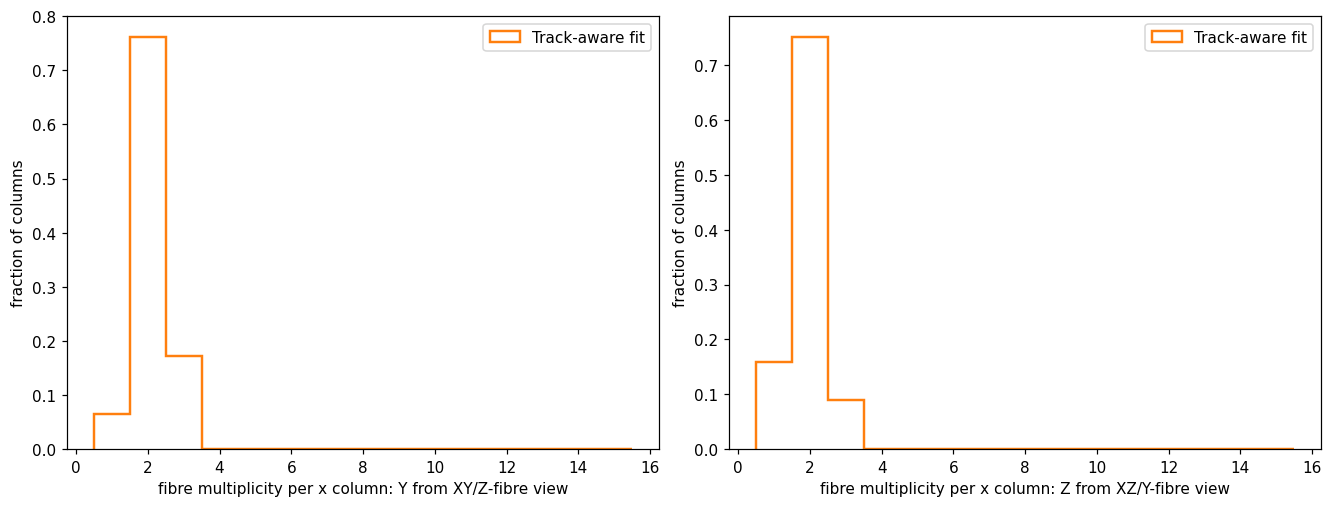

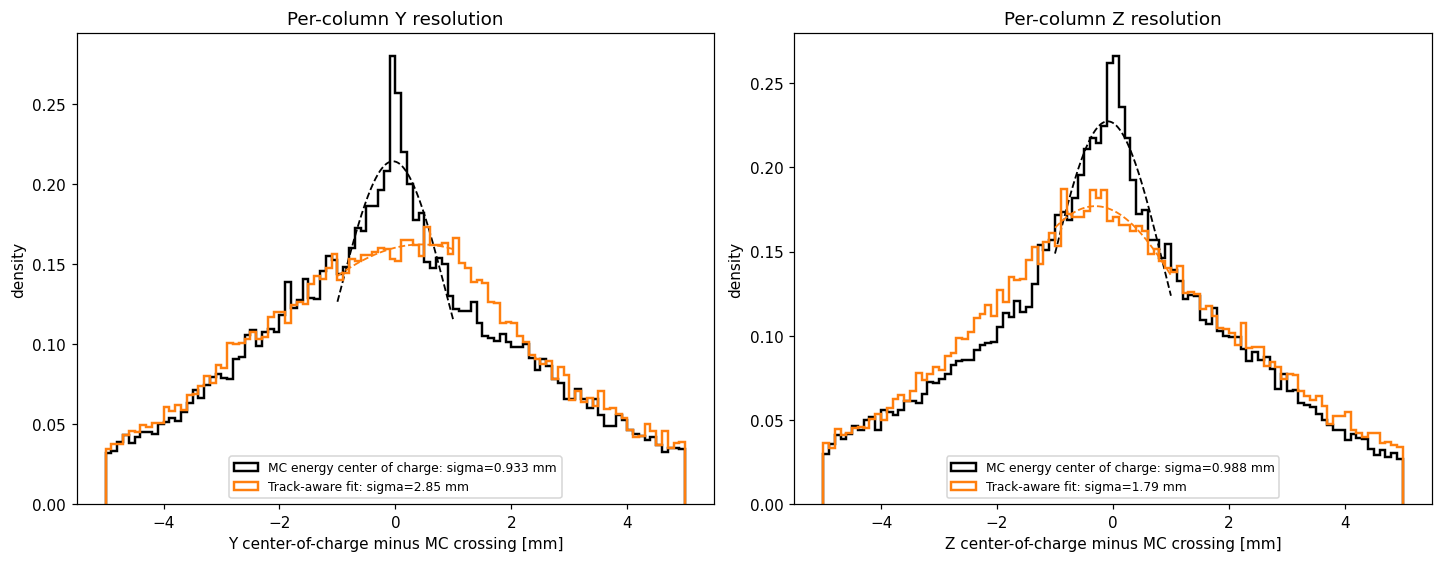

In [10]:
COLUMN_RESIDUAL_DISPLAY_RANGE_MM = (-5, 5)
COLUMN_RESIDUAL_GAUSS_RANGE_MM = (-1, 1)
# Default: new track-aware result only. Add 'Previous fit' for the legacy reconstruction.
TRANSVERSE_POSITION_SAMPLES = ['Track-aware fit']
all_column_positions, mc_column_positions = transverse_column_positions(runs, segments, track_points, use_selected=True)
column_positions = {label: all_column_positions[label][all_column_positions[label].event.astype(int).isin(accepted)] for label in TRANSVERSE_POSITION_SAMPLES}
mc_column_positions = mc_column_positions[mc_column_positions.event.astype(int).isin(accepted)]
multiplicity_summary, multiplicity_figure = plot_transverse_multiplicity(column_positions)
display(multiplicity_summary)
column_resolution, column_resolution_figure = plot_transverse_column_resolution(column_positions, mc_column_positions, display_range=COLUMN_RESIDUAL_DISPLAY_RANGE_MM, fit_range=COLUMN_RESIDUAL_GAUSS_RANGE_MM, bins=100)
display(column_resolution)

## Average transverse multiplicity versus scattering length
This scans every available track-aware output for `LIGHTMAP_MODEL`. Multiplicity is the number of selected fibres in a populated x column, averaged over the two transverse views. Error bars are standard errors on the mean.

Multiplicity 0.25 mm: /home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie/0p7GeV/maps/10bin_5m_double_hg_0p25mm_g-0p5_rfb-0p75_fibre-1p0mm_scin-ri-1p48_100kPhotons/global_fit_columns_track_aware_mip_1mm.root
Multiplicity 0.4 mm: /home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie/0p7GeV/maps/10bin_5m_double_hg_0p4mm_g-0p5_rfb-0p75_fibre-1p0mm_scin-ri-1p48_100kPhotons/global_fit_columns_track_aware_mip_1mm.root
Multiplicity 0.7 mm: /home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie/0p7GeV/maps/10bin_5m_double_hg_0p7mm_g-0p5_rfb-0p75_fibre-1p0mm_scin-ri-1p48_100kPhotons/global_fit_columns_track_aware_mip_1mm.root
Multiplicity 1 mm: /home/tlux/HK/ND280++/LFGD_Recon_Simu/Studies/LightmapsStudie/0p7GeV/maps/10bin_5m_double_hg_1p0mm_g-0p5_rfb-0p75_fibre-1p0mm_scin-ri-1p48_100kPhotons/global_fit_columns_track_aware_mip_1mm.root


,scatter_length_mm,columns,mean_multiplicity,sem_multiplicity,median_multiplicity
0,0.25,111108,2.014424,0.001465,2.0
1,0.40,111159,2.141957,0.001509,2.0
2,0.70,111381,2.347025,0.001587,2.0
3,1.00,111489,2.489574,0.001574,2.5


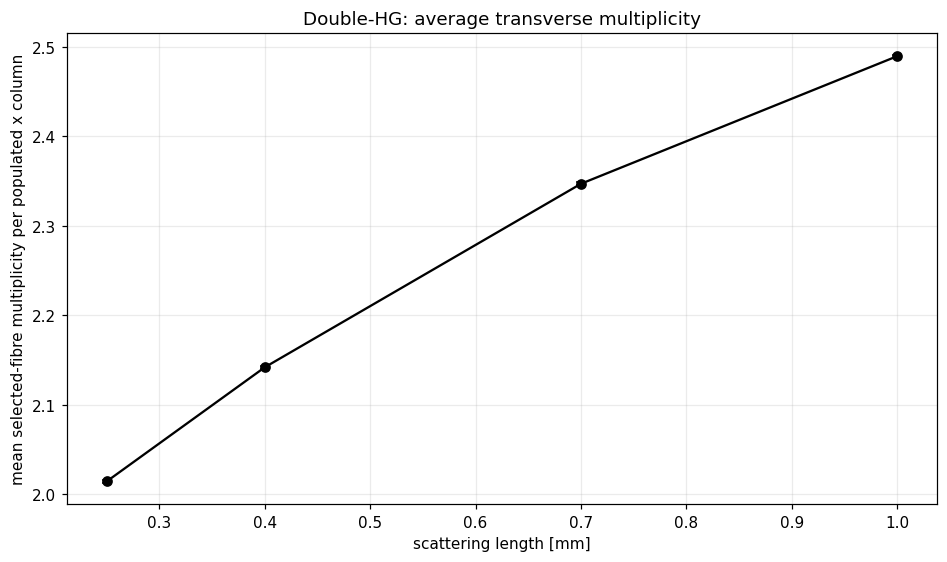

In [11]:
multiplicity_scan, multiplicity_scan_figure = scatter_length_multiplicity_scan(available, LIGHTMAP_MODEL, fit_filename='global_fit_columns_track_aware_mip_1mm.root')
display(multiplicity_scan)

## Track-aware diagnostics
These quantities exist only in the new output. A merge count above zero identifies events where separated aligned DBSCAN components were bridged.

In [12]:
new_fit = runs['Track-aware fit']['fit']
diagnostic_columns = [c for c in ['event','track_clusters_found','track_clusters_merged','track_branches_rejected'] if c in new_fit]
diagnostics = new_fit[diagnostic_columns].copy()
display(diagnostics.describe())
if 'track_clusters_merged' in diagnostics:
    print('Events with merged components:', int((diagnostics.track_clusters_merged > 0).sum()))
if 'track_branches_rejected' in diagnostics:
    print('Events with rejected branch fibres:', int((diagnostics.track_branches_rejected > 0).sum()))
    display(diagnostics.sort_values('track_branches_rejected', ascending=False).head(20))

,event,track_clusters_found,track_clusters_merged,track_branches_rejected
count,505.000000,505.000000,505.000000,505.000000
mean,252.000000,3.697030,0.421782,10.659406
std,145.925209,1.199078,0.754826,9.680144
min,0.000000,3.000000,0.000000,0.000000
25%,126.000000,3.000000,0.000000,5.000000
50%,252.000000,3.000000,0.000000,8.000000
75%,378.000000,4.000000,1.000000,14.000000
max,504.000000,13.000000,4.000000,103.000000


Events with merged components: 142
Events with rejected branch fibres: 504


,event,track_clusters_found,track_clusters_merged,track_branches_rejected
101,101,3,0,103
233,233,4,0,64
281,281,4,0,59
326,326,3,0,49
408,408,3,0,48
179,179,3,0,43
12,12,3,0,43
258,258,3,0,40
492,492,3,0,40
218,218,3,0,39


## MIP-regularised column charges (charge-only step)

This optional section loads `global_fit_columns_track_aware_mip_1mm.root`. The MIP prior changes the fitted column charges but **does not move the reconstructed track**. The final section below handles the separate RL segment-position refinement.

,events,prior_converged,prior_stalled,prior_converged_fraction,eligible_columns,charge_per_energy,mean_regularization_shift,rms_regularization_shift,median_prior_iterations,median_prior_penalty
lightmap,,,,,,,,,,
Track-aware stage 3,505,504,0,0.99802,54392,74.718714,0.025833,0.195732,26.0,0.011139


,columns,charge_per_mc_energy,qc_reco_mean,qc_reco_std,qc_true_mean,qc_true_std
lightmap,,,,,,
Track-aware stage 3,55402,74.718714,1.847918,0.760714,1.78637,0.727892


,charge_per_mc_energy,gaussian_bias,sigma_over_E,fit_low,fit_high,fit_entries,all_positive_mc_columns
lightmap,,,,,,,
Track-aware stage 3,74.718714,0.025018,0.196501,-0.5,0.5,52048,55120


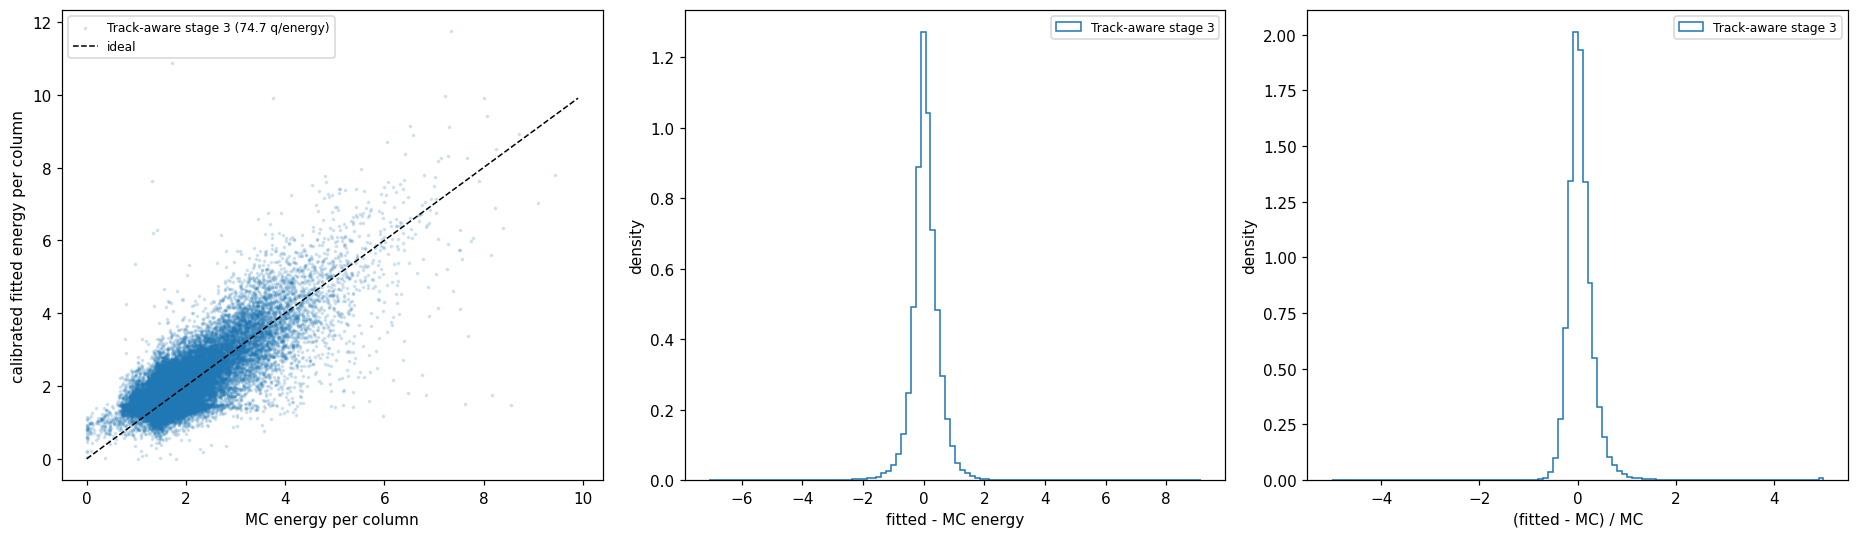

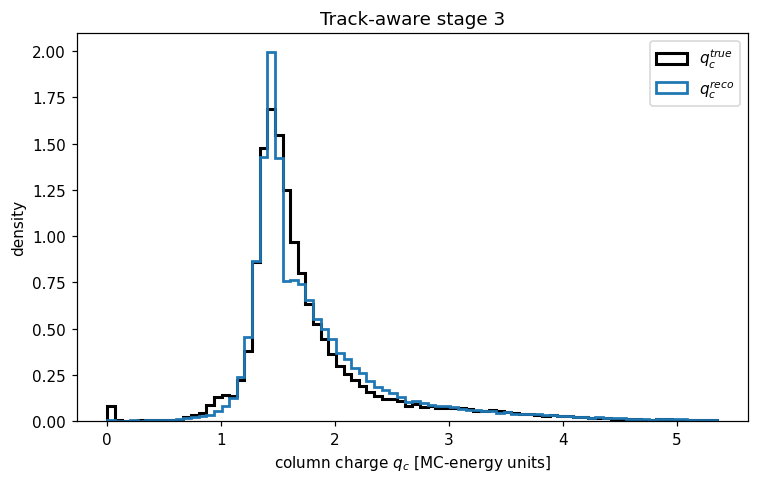

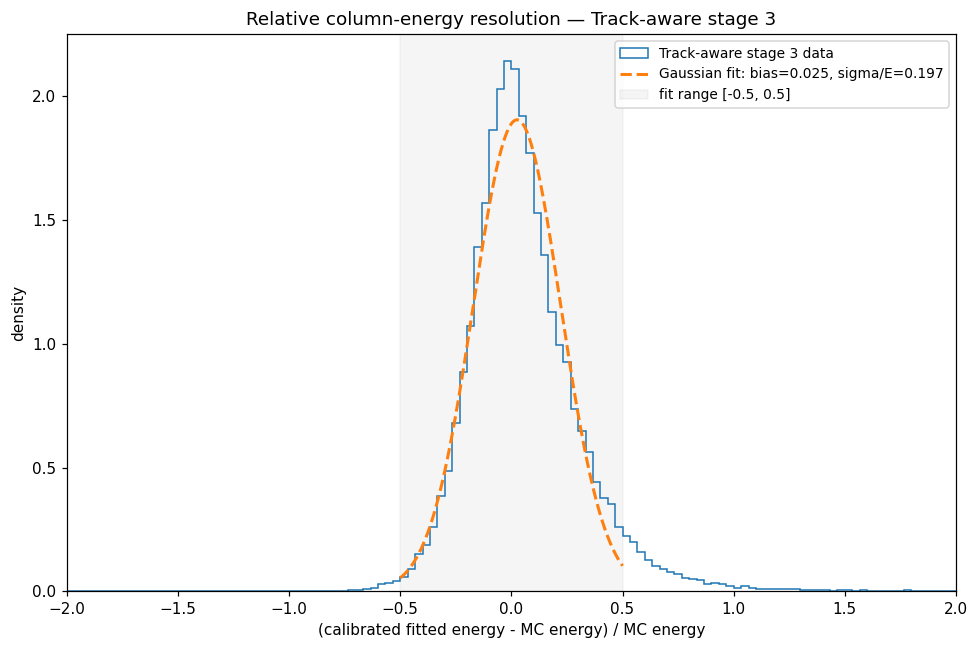

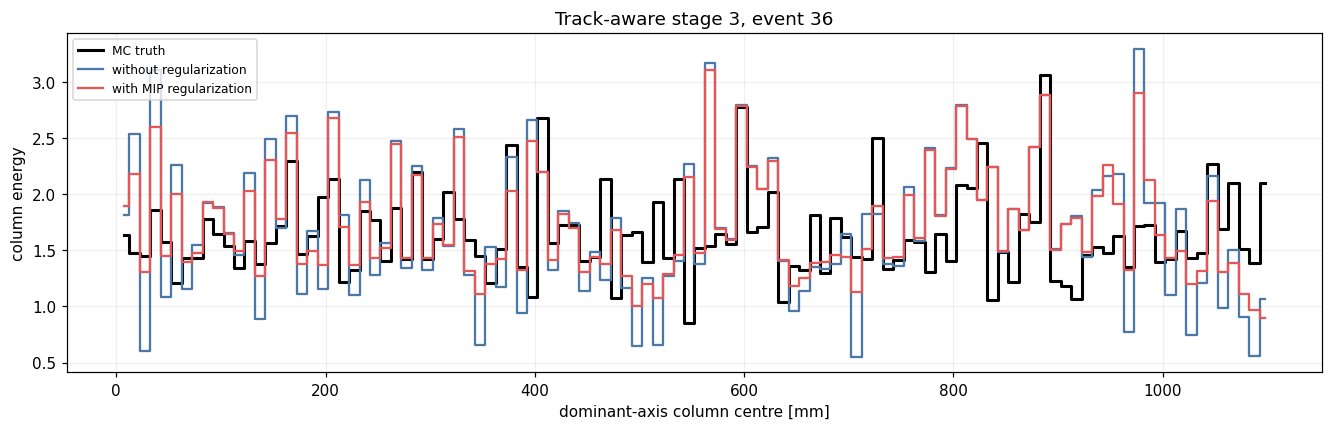

In [13]:
STAGE3_FILENAME = 'global_fit_columns_track_aware_mip_1mm.root'
STAGE3_QC_BINS = 80
STAGE3_QC_DISPLAY_RANGE = None  # e.g. (0.0, 4.0)
STAGE3_RESIDUAL_DISPLAY_RANGE = (-2.0, 2.0)
STAGE3_RESIDUAL_FIT_RANGE = (-0.5, 0.5)  # Gaussian fit interval
STAGE3_EVENT = 36
stage3_file = DIRECTORY / STAGE3_FILENAME
if not stage3_file.exists():
    print(f'Stage-3 file not found; skipping: {stage3_file}')
else:
    stage3_studies = load_studies({'Track-aware stage 3': stage3_file})
    stage3_segments, stage3_track_points = load_truth(stage3_file)
    stage3_raw = {'Track-aware stage 3': match_columns_to_truth(
        stage3_studies['Track-aware stage 3']['columns'], stage3_segments,
        stage3_track_points, mode='all')}
    stage3_variants = mip_prior_variants(stage3_studies, stage3_raw)
    if not stage3_variants:
        print(f'No enabled MIP-prior solution in {stage3_file}')
    else:
        display(mip_prior_summary(stage3_studies, stage3_variants))
        stage3_matched = {label: values['regularized'] for label, values in stage3_variants.items()}
        plot_column_resolution(stage3_matched);
        stage3_qc_summary, stage3_qc_figure = plot_column_charge_distributions(
            stage3_matched, bins=STAGE3_QC_BINS, histogram_range=STAGE3_QC_DISPLAY_RANGE)
        display(stage3_qc_summary)
        stage3_resolution, stage3_resolution_figures = plot_relative_energy_resolution(
            stage3_matched, display_range=STAGE3_RESIDUAL_DISPLAY_RANGE,
            gaussian_fit_range=STAGE3_RESIDUAL_FIT_RANGE)
        display(stage3_resolution)
        plot_mip_event_profiles(stage3_variants, STAGE3_EVENT);

## Third stage: RL segment-position refinement

The offline Richardson–Lucy stage can redistribute charge and move each column segment transversely, subject to the aggregate residual-PDF and curvature priors. Set the RL filename below to the output produced for the selected lightmap. The section is skipped when that file is absent.

,events,converged,stalled,median iterations,median curvature RMS [mm]
0,505,5,4,100.0,0.346599


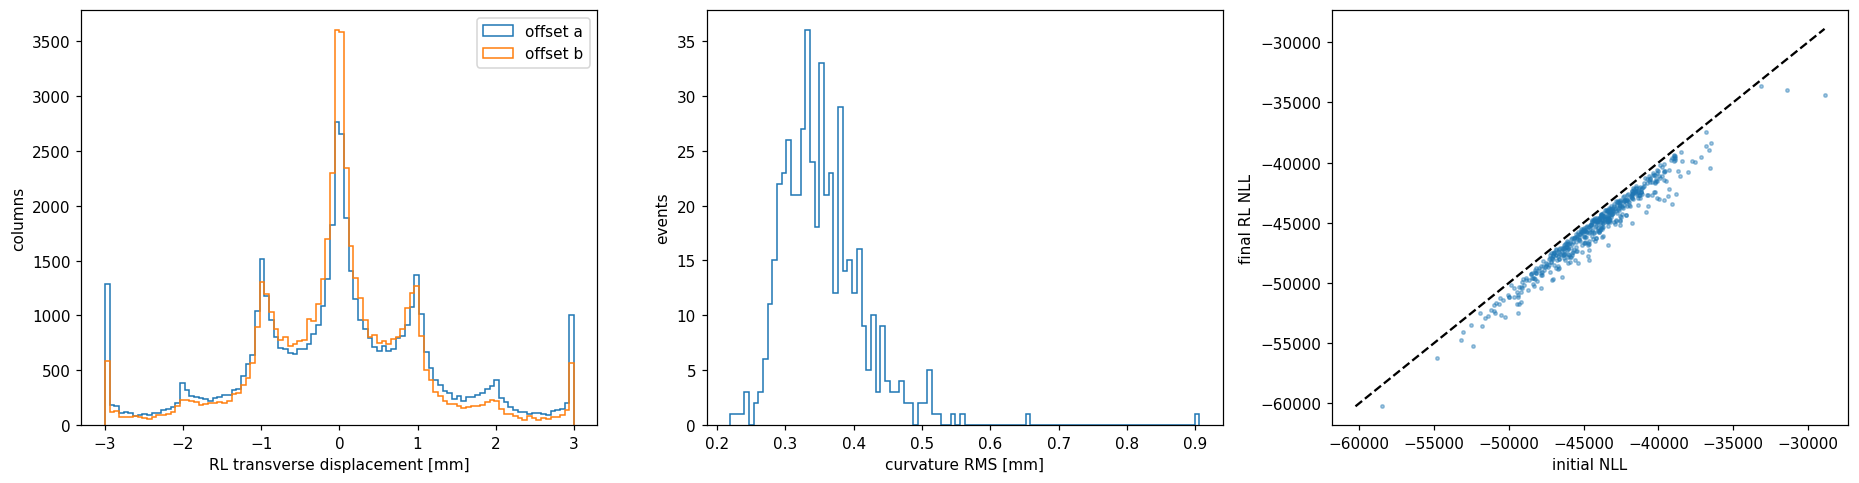

In [16]:
RL_FILENAME = 'rl_segments_all_flexible.root'
#RL_FILENAME = 'rl_segments_all_objective.root'
RL_SOLUTION = 'regularized'  # 'regularized' or 'best-nll'
RL_EVENT = 36
rl_file = DIRECTORY / RL_FILENAME
rl_available = rl_file.exists()
if not rl_available:
    print(f'RL stage not found; run the refinement first or change RL_FILENAME: {rl_file}')
else:
    rl_fit = _tree_frame(rl_file, 'rl_fit')
    rl_columns = _tree_frame(rl_file, 'rl_columns')
    display(pd.DataFrame({
        'events': [rl_fit.event.nunique()],
        'converged': [int((rl_fit.converged == 1).sum())],
        'stalled': [int((rl_fit.stalled == 1).sum())],
        'median iterations': [rl_fit.iterations.median()],
        'median curvature RMS [mm]': [rl_fit.curvature_rms_mm.median()]}))
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    axes[0].hist(rl_columns.offset_a_mm, bins=100, histtype='step', label='offset a')
    axes[0].hist(rl_columns.offset_b_mm, bins=100, histtype='step', label='offset b')
    axes[0].set(xlabel='RL transverse displacement [mm]', ylabel='columns'); axes[0].legend()
    axes[1].hist(rl_fit.curvature_rms_mm, bins=100, histtype='step')
    axes[1].set(xlabel='curvature RMS [mm]', ylabel='events')
    axes[2].scatter(rl_fit.initial_nll, rl_fit.final_nll, s=5, alpha=.4)
    lo = min(rl_fit.initial_nll.min(), rl_fit.final_nll.min()); hi = max(rl_fit.initial_nll.max(), rl_fit.final_nll.max())
    axes[2].plot([lo, hi], [lo, hi], 'k--'); axes[2].set(xlabel='initial NLL', ylabel='final RL NLL')
    fig.tight_layout()

In [17]:
if rl_available:
    rl_event_widget = interactive_rl_event(
        runs['Track-aware fit'], truth, rl_columns, initial_event=RL_EVENT)
else:
    print(f'RL file unavailable: {rl_file}')
# Widget-free fallback:
# draw_rl_event(runs['Track-aware fit'], truth, rl_columns, event=36, solution='regularized')

Output()